# Python Assignment 15 :Clustering 

In [24]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_excel("EastWestAirlines.xlsx" , sheet_name = "data")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [27]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [28]:
df.shape

(3999, 12)

In [29]:
df.columns

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [30]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [31]:
df = df.drop(['ID#'], axis=1)

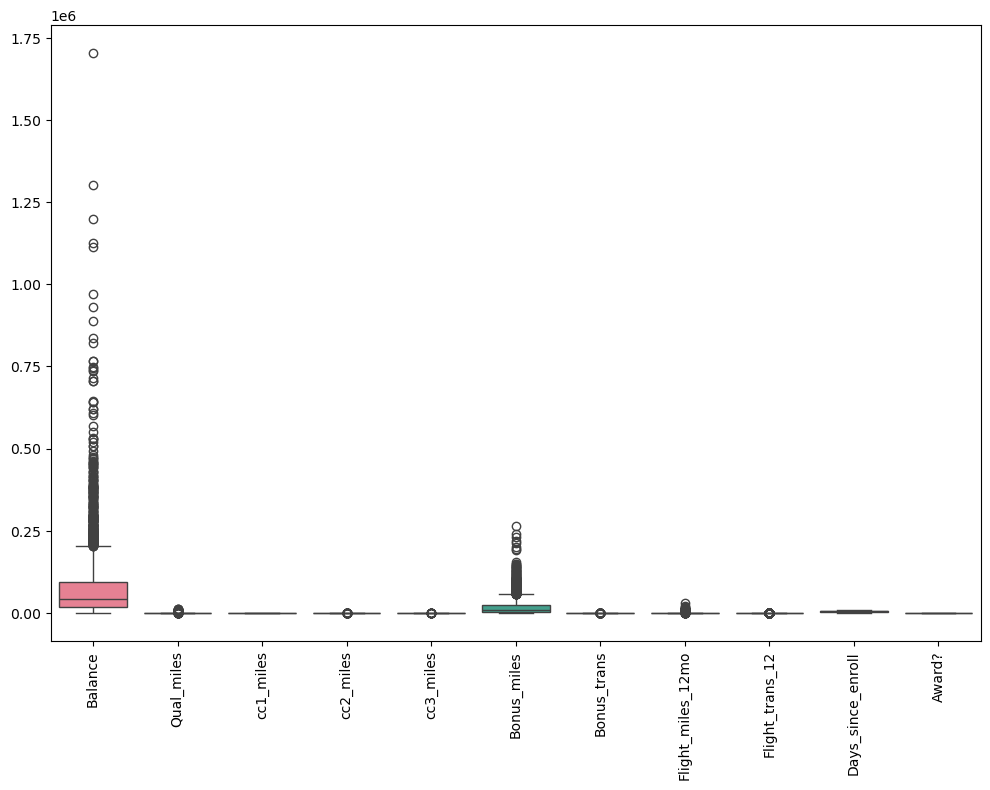

In [32]:
# box plot 

plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()


In [33]:
# featur scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)


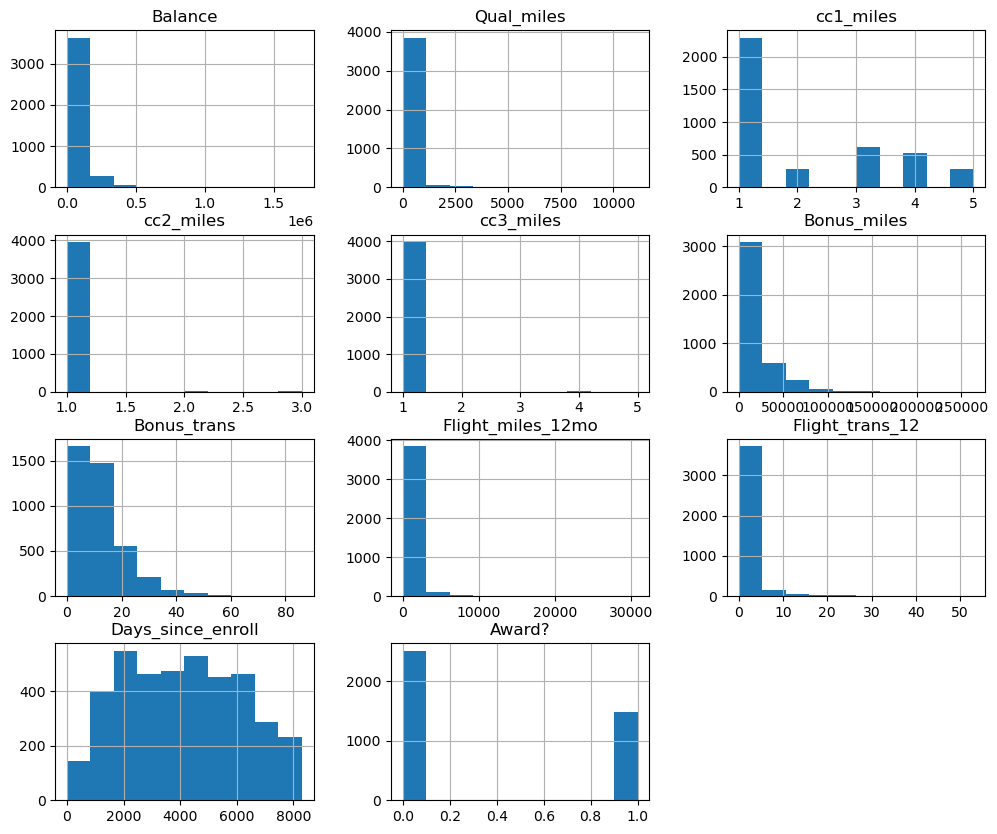

In [34]:
# hist plot 

df.hist(figsize=(12,10))
plt.show()


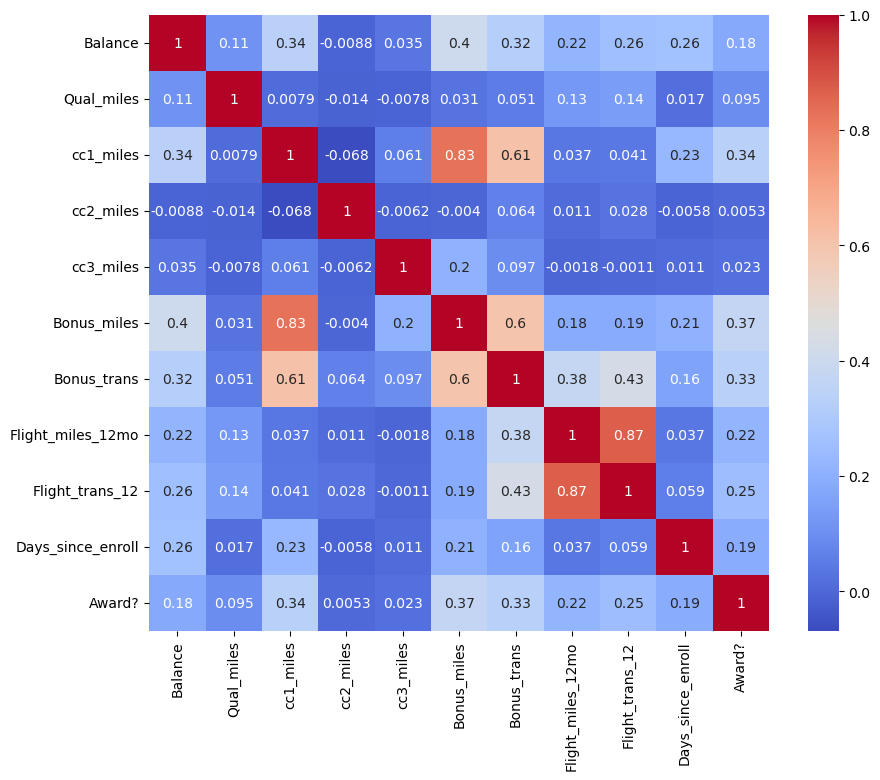

In [35]:
# corr plot

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [37]:
# pair plot 

# sns.pairplot(df)
# plt.show()


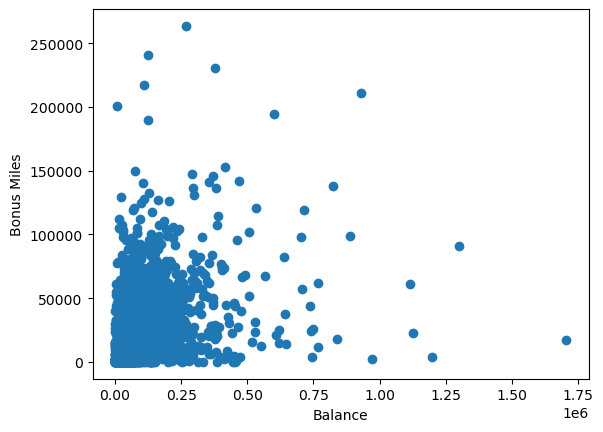

In [38]:
# scatter plot 

plt.scatter(df['Balance'], df['Bonus_miles'])
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.show()


### K-Means Clustering

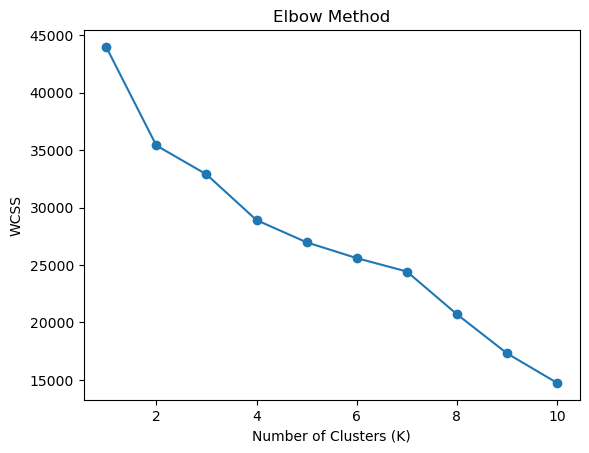

In [47]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [48]:
kmeans = KMeans(n_clusters=4, random_state=42)  # change K based on elbow
kmeans_labels = kmeans.fit_predict(df_scaled)

df['KMeans_Cluster'] = kmeans_labels

In [49]:
from sklearn.metrics import silhouette_score

score = silhouette_score(df_scaled, kmeans_labels)
print("Silhouette Score (K-Means):", score)


Silhouette Score (K-Means): 0.19071186813310886


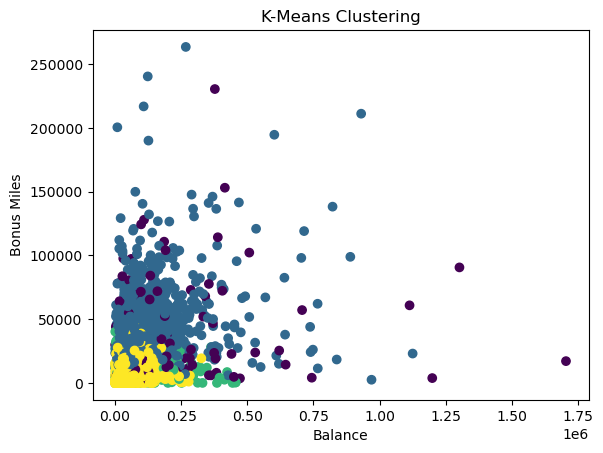

In [50]:
plt.scatter(df['Balance'], df['Bonus_miles'], c=kmeans_labels)
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("K-Means Clustering")
plt.show()


### DBSCAN 

In [51]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(df_scaled)

df['DBSCAN_Cluster'] = db_labels


In [52]:
print("Unique clusters:", np.unique(db_labels))

Unique clusters: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [53]:
from sklearn.metrics import silhouette_score

# remove noise for silhouette
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    score = silhouette_score(df_scaled[mask], db_labels[mask])
    print("Silhouette Score (DBSCAN):", score)
else:
    print("Not enough clusters for silhouette score")


Silhouette Score (DBSCAN): 0.14397923390835202


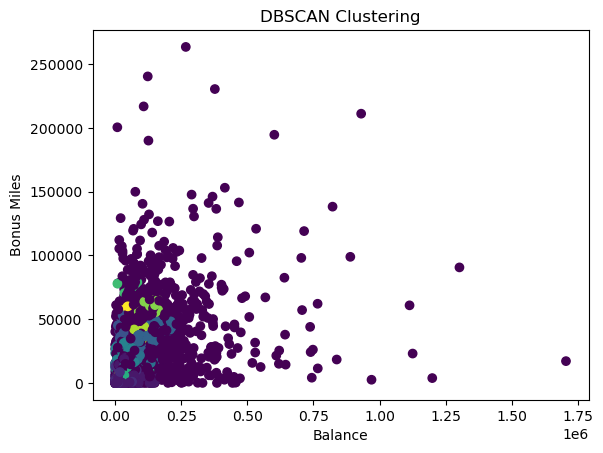

In [54]:
plt.scatter(df['Balance'], df['Bonus_miles'], c=db_labels)
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("DBSCAN Clustering")
plt.show()


In [55]:
for eps in [0.3, 0.5, 0.7, 1.0]:
    for min_samples in [3,5,10]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(df_scaled)
        print(f"eps={eps}, min_samples={min_samples}, clusters={len(set(labels))}")


eps=0.3, min_samples=3, clusters=76
eps=0.3, min_samples=5, clusters=24
eps=0.3, min_samples=10, clusters=7
eps=0.5, min_samples=3, clusters=41
eps=0.5, min_samples=5, clusters=17
eps=0.5, min_samples=10, clusters=10
eps=0.7, min_samples=3, clusters=33
eps=0.7, min_samples=5, clusters=17
eps=0.7, min_samples=10, clusters=11
eps=1.0, min_samples=3, clusters=11
eps=1.0, min_samples=5, clusters=7
eps=1.0, min_samples=10, clusters=4


In [56]:
df.groupby('KMeans_Cluster').mean()


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,
0,193291.147436,795.455128,2.179487,1.038462,1.000000,32292.288462,27.628205,5530.230769,16.211538,4688.070513,0.820513,-1.000000
1,122119.899548,151.724887,3.885068,1.002715,1.043439,43772.394570,19.398190,366.520362,1.087783,4777.394570,0.687783,1.514027
2,59693.586570,112.733010,1.372168,1.031553,1.000809,6311.116505,8.456311,258.830097,0.806634,5744.810680,0.296117,0.937702
3,36920.458056,96.690413,1.269640,1.006658,1.000000,4897.208389,6.790280,167.861518,0.509321,2236.466711,0.151132,0.880826


In [57]:
df.groupby('DBSCAN_Cluster').mean()


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
DBSCAN_Cluster,,,,,,,,,,,,
-1,134500.365888,407.865534,2.685775,1.036801,1.034678,31603.530078,17.836518,1193.485492,3.496108,4690.736023,0.590234,1.460722
0,28053.443909,0.000000,1.000000,1.000000,1.000000,1946.549897,4.842395,57.693737,0.217481,3482.193393,0.000000,2.657949
1,29113.324627,0.000000,1.000000,1.000000,1.000000,3672.082090,4.929104,146.432836,0.470149,4031.078358,1.000000,2.462687
2,53130.400000,0.000000,2.000000,1.000000,1.000000,11096.400000,21.600000,50.000000,0.200000,6981.000000,0.000000,2.000000
3,50411.552632,0.000000,4.000000,1.000000,1.000000,37148.166667,15.342105,60.666667,0.210526,4715.043860,1.000000,1.000000
4,101333.108108,0.000000,4.000000,1.000000,1.000000,36288.072072,15.648649,20.720721,0.063063,4702.090090,0.000000,1.000000
5,75997.736170,0.000000,3.000000,1.000000,1.000000,17846.829787,14.663830,37.425532,0.131915,4040.851064,0.000000,2.395745
6,41971.895954,0.000000,3.000000,1.000000,1.000000,18654.855491,15.393064,42.196532,0.173410,4425.248555,1.000000,1.184971
7,138516.800000,0.000000,2.000000,1.000000,1.000000,8307.800000,11.600000,0.000000,0.000000,7823.200000,0.000000,2.000000


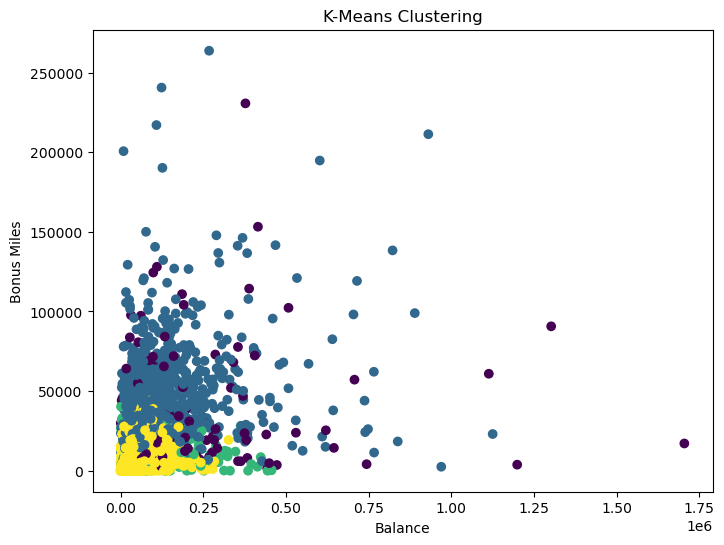

In [60]:
# k mesna visualization

plt.figure(figsize=(8,6))
plt.scatter(df['Balance'], df['Bonus_miles'], 
            c=df['KMeans_Cluster'], cmap='viridis')

plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("K-Means Clustering")
plt.show()


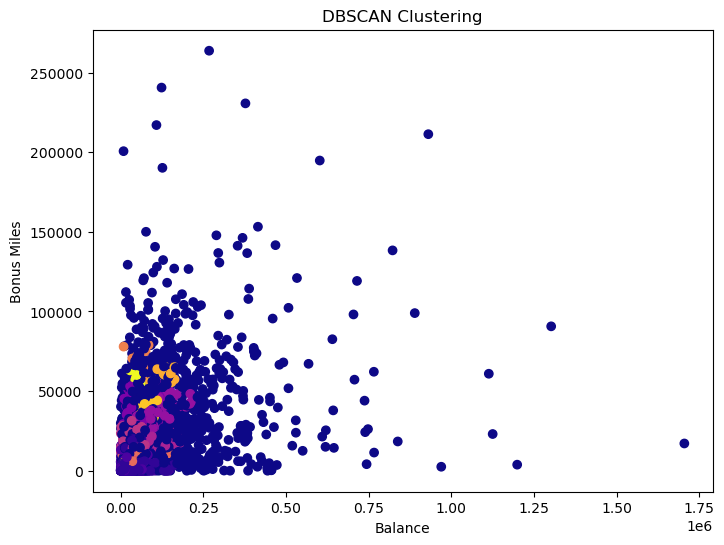

In [61]:
# DBSCAN visualization

plt.figure(figsize=(8,6))
plt.scatter(df['Balance'], df['Bonus_miles'], 
            c=df['DBSCAN_Cluster'], cmap='plasma')

plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("DBSCAN Clustering")
plt.show()




In [62]:
# evaluaition 

from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(df_scaled, df['KMeans_Cluster'])
print("Silhouette Score (K-Means):", kmeans_score)


Silhouette Score (K-Means): 0.19071186813310886


In [63]:
from sklearn.metrics import silhouette_score

db_labels = df['DBSCAN_Cluster']

# remove noise points
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    dbscan_score = silhouette_score(df_scaled[mask], db_labels[mask])
    print("Silhouette Score (DBSCAN):", dbscan_score)
else:
    print("Not enough clusters to calculate silhouette score")


Silhouette Score (DBSCAN): 0.14397923390835202


In [64]:
print("K-Means Score:", kmeans_score)
print("DBSCAN Score:", dbscan_score)


K-Means Score: 0.19071186813310886
DBSCAN Score: 0.14397923390835202


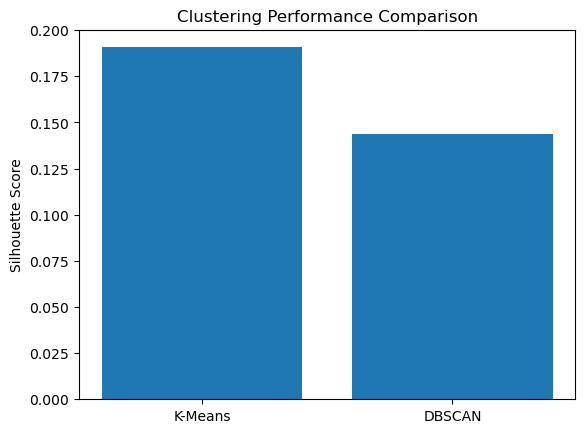

In [65]:
import matplotlib.pyplot as plt

scores = [kmeans_score, dbscan_score]
labels = ['K-Means', 'DBSCAN']

plt.bar(labels, scores)
plt.ylabel("Silhouette Score")
plt.title("Clustering Performance Comparison")
plt.show()
